In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
main_df= pd.read_csv("chiller_predictive_maintenance_dataset.csv")
main_df.sample(5)

,Sample_ID,Split,Rule_ID,Expected_Fault_Label,F36,F15,H25,H24,H64,H15,...,Evaporator_Electrical_Fault,Evaporator_FlowSwitch_Fault,Compressor_General_Fault,Compressor_Contactor_Fault,Compressor_Leak,Compressor_OilLoss,Compressor_SuperheatIncreaseNeeded,General_Electrical_Fault,General_LowPerformance,General_UnitUndersizedOversized
3052,train_03053,train,NaN,NaN,3.6378,8.8413,38.0821,35.5342,42.9820,87.7801,...,0.16600,0.51297,0.50151,0.41580,0.46995,0.41580,0.16632,0.16600,0.44779,0.55221
11104,train_11105,train,NaN,NaN,20.7456,9.3752,19.5369,49.1024,17.4945,70.9469,...,0.16600,0.50000,0.65078,0.33688,0.33688,0.33688,0.16756,0.00000,0.00000,0.00000
4003,train_04004,train,NaN,NaN,12.4177,7.5267,31.8680,57.6639,35.1556,59.2123,...,0.16600,0.16600,0.57407,0.17099,0.42593,0.17099,0.17099,0.20940,0.22833,0.77167
241,train_00242,train,NaN,NaN,-5.0471,7.1358,30.7113,42.4205,36.6376,53.1038,...,0.16600,0.67751,0.41405,0.16617,0.58595,0.16617,0.16617,0.00000,0.00000,0.00000
10418,train_10419,train,NaN,NaN,2.6431,2.4953,28.4096,50.7884,32.6903,43.3832,...,0.19552,0.19552,0.53041,0.18016,0.46959,0.18016,0.18016,0.17223,0.21362,0.65694


In [3]:
main_df[["Rule_ID", "Expected_Fault_Label"]].isna().value_counts()

Rule_ID  Expected_Fault_Label
True     True                    12000
False    False                      30
Name: count, dtype: int64

In [4]:
train_df = main_df[main_df["Split"]=='train'].copy()


holdout_df = main_df[main_df["Split"]=="holdout_manual"].copy()

In [5]:
train_df.sample(5)

,Sample_ID,Split,Rule_ID,Expected_Fault_Label,F36,F15,H25,H24,H64,H15,...,Evaporator_Electrical_Fault,Evaporator_FlowSwitch_Fault,Compressor_General_Fault,Compressor_Contactor_Fault,Compressor_Leak,Compressor_OilLoss,Compressor_SuperheatIncreaseNeeded,General_Electrical_Fault,General_LowPerformance,General_UnitUndersizedOversized
2167,train_02168,train,NaN,NaN,25.0079,8.1333,30.0538,41.1910,46.1710,61.0535,...,0.166,0.65313,0.00000,0.00000,0.00000,0.00000,0.00000,0.17476,0.62614,0.37386
9298,train_09299,train,NaN,NaN,31.0203,5.4737,24.3727,37.8613,26.4928,46.5560,...,0.000,0.00000,0.48764,0.16616,0.16616,0.16616,0.51236,0.00000,0.00000,0.00000
7338,train_07339,train,NaN,NaN,45.6621,6.3418,32.2208,43.9052,48.9644,64.9480,...,0.000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.16600,0.49877,0.50123
10615,train_10616,train,NaN,NaN,4.8722,2.6277,38.1469,35.8424,28.6292,65.5223,...,0.166,0.50000,0.58477,0.18995,0.41528,0.18995,0.16675,0.16600,0.16600,0.83400
4472,train_04473,train,NaN,NaN,41.8350,0.0174,26.2527,30.1276,25.1518,77.8730,...,0.166,0.50000,0.55625,0.39656,0.39656,0.39656,0.16600,0.00000,0.00000,0.00000


In [6]:
train_df.columns

Index(['Sample_ID', 'Split', 'Rule_ID', 'Expected_Fault_Label', 'F36', 'F15',
       'H25', 'H24', 'H64', 'H15', 'F14', 'H42', 'Mode_1Cool_2Heat', 'H23F',
       'H23C', 'P02', 'H20', 'P03', 'F37', 'F39', 'H62',
       'Chiller_Condenser_Fault', 'Chiller_ExpansionValve_Fault',
       'Chiller_Evaporator_Fault', 'Chiller_Compressor_Fault',
       'Chiller_General_Fault', 'Condenser_Valve_Fault',
       'Condenser_Filter_Fault', 'Condenser_GasChargeNeeded',
       'Condenser_Fan_Fault', 'Condenser_Coil_Fault', 'Condenser_GasLeak',
       'Evaporator_LiquidLeak', 'Evaporator_Valve_Fault',
       'Evaporator_StrainerFilter_Fault', 'Evaporator_Piping_Fault',
       'Evaporator_HeatExchanger_Fault', 'Evaporator_Electrical_Fault',
       'Evaporator_FlowSwitch_Fault', 'Compressor_General_Fault',
       'Compressor_Contactor_Fault', 'Compressor_Leak', 'Compressor_OilLoss',
       'Compressor_SuperheatIncreaseNeeded', 'General_Electrical_Fault',
       'General_LowPerformance', 'General_UnitUnd

In [7]:
input_cols = ["F36","F15","H25","H24","H64","H15","F14","H42","Mode_1Cool_2Heat","H23F","H23C","P02","H20","P03","F37","F39","H62"]
output_cols = ['Chiller_Condenser_Fault', 'Chiller_ExpansionValve_Fault',
       'Chiller_Evaporator_Fault', 'Chiller_Compressor_Fault',
       'Chiller_General_Fault', 'Condenser_Valve_Fault',
       'Condenser_Filter_Fault', 'Condenser_GasChargeNeeded',
       'Condenser_Fan_Fault', 'Condenser_Coil_Fault', 'Condenser_GasLeak',
       'Evaporator_LiquidLeak', 'Evaporator_Valve_Fault',
       'Evaporator_StrainerFilter_Fault', 'Evaporator_Piping_Fault',
       'Evaporator_HeatExchanger_Fault', 'Evaporator_Electrical_Fault',
       'Evaporator_FlowSwitch_Fault', 'Compressor_General_Fault',
       'Compressor_Contactor_Fault', 'Compressor_Leak', 'Compressor_OilLoss',
       'Compressor_SuperheatIncreaseNeeded', 'General_Electrical_Fault',
       'General_LowPerformance', 'General_UnitUndersizedOversized']


In [8]:
train_df.isnull().sum()

Sample_ID                                 0
Split                                     0
Rule_ID                               12000
Expected_Fault_Label                  12000
F36                                       0
F15                                       0
H25                                       0
H24                                       0
H64                                       0
H15                                       0
F14                                       0
H42                                       0
Mode_1Cool_2Heat                          0
H23F                                      0
H23C                                      0
P02                                       0
H20                                       0
P03                                       0
F37                                       0
F39                                       0
H62                                       0
Chiller_Condenser_Fault                   0
Chiller_ExpansionValve_Fault    

In [9]:
train_df[train_df.duplicated()]

,Sample_ID,Split,Rule_ID,Expected_Fault_Label,F36,F15,H25,H24,H64,H15,...,Evaporator_Electrical_Fault,Evaporator_FlowSwitch_Fault,Compressor_General_Fault,Compressor_Contactor_Fault,Compressor_Leak,Compressor_OilLoss,Compressor_SuperheatIncreaseNeeded,General_Electrical_Fault,General_LowPerformance,General_UnitUndersizedOversized


In [10]:
train_df.dtypes

Sample_ID                              object
Split                                  object
Rule_ID                                object
Expected_Fault_Label                   object
F36                                   float64
F15                                   float64
H25                                   float64
H24                                   float64
H64                                   float64
H15                                   float64
F14                                   float64
H42                                   float64
Mode_1Cool_2Heat                        int64
H23F                                  float64
H23C                                  float64
P02                                   float64
H20                                   float64
P03                                   float64
F37                                   float64
F39                                   float64
H62                                     int64
Chiller_Condenser_Fault           

In [11]:
train_df[input_cols].describe()

,F36,F15,H25,H24,H64,H15,F14,H42,Mode_1Cool_2Heat,H23F,H23C,P02,H20,P03,F37,F39,H62
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,20.096682,5.123471,31.415009,47.610564,32.934577,62.603347,80.607557,7.769503,1.503167,6.526537,10.008911,0.646686,2.513656,2.226474,13.760827,9.902933,0.504417
std,15.486435,2.812657,6.437963,8.528375,8.156391,13.473488,45.984947,3.004929,0.500011,3.251063,2.009635,0.393197,1.442385,1.075205,5.292267,5.751005,0.500001
min,-9.986600,0.000500,18.006000,30.001800,16.003700,35.003300,0.014600,1.689900,1.000000,0.005400,6.000400,0.000400,0.000300,0.001100,3.007600,-0.999800,0.000000
25%,7.437575,2.710225,28.029425,41.601950,28.279800,52.827800,40.434975,5.428675,1.000000,4.023500,8.511025,0.325800,1.252975,1.569750,9.694550,5.350275,0.000000
50%,20.111850,5.085400,31.484350,47.611000,33.037500,62.545400,81.142000,7.808750,2.000000,6.534700,10.017250,0.592850,2.508850,2.242800,13.902300,9.692450,1.000000
75%,32.814650,7.586700,34.878275,53.637900,37.588325,72.366350,120.470650,10.065375,2.000000,9.034875,11.513850,0.923700,3.789050,2.885625,17.944825,13.989425,1.000000
max,49.994000,9.999100,44.998500,64.994000,49.999000,89.992900,159.978000,13.812100,2.000000,12.998700,13.999200,1.499700,4.999900,4.498600,23.991000,21.999600,1.000000


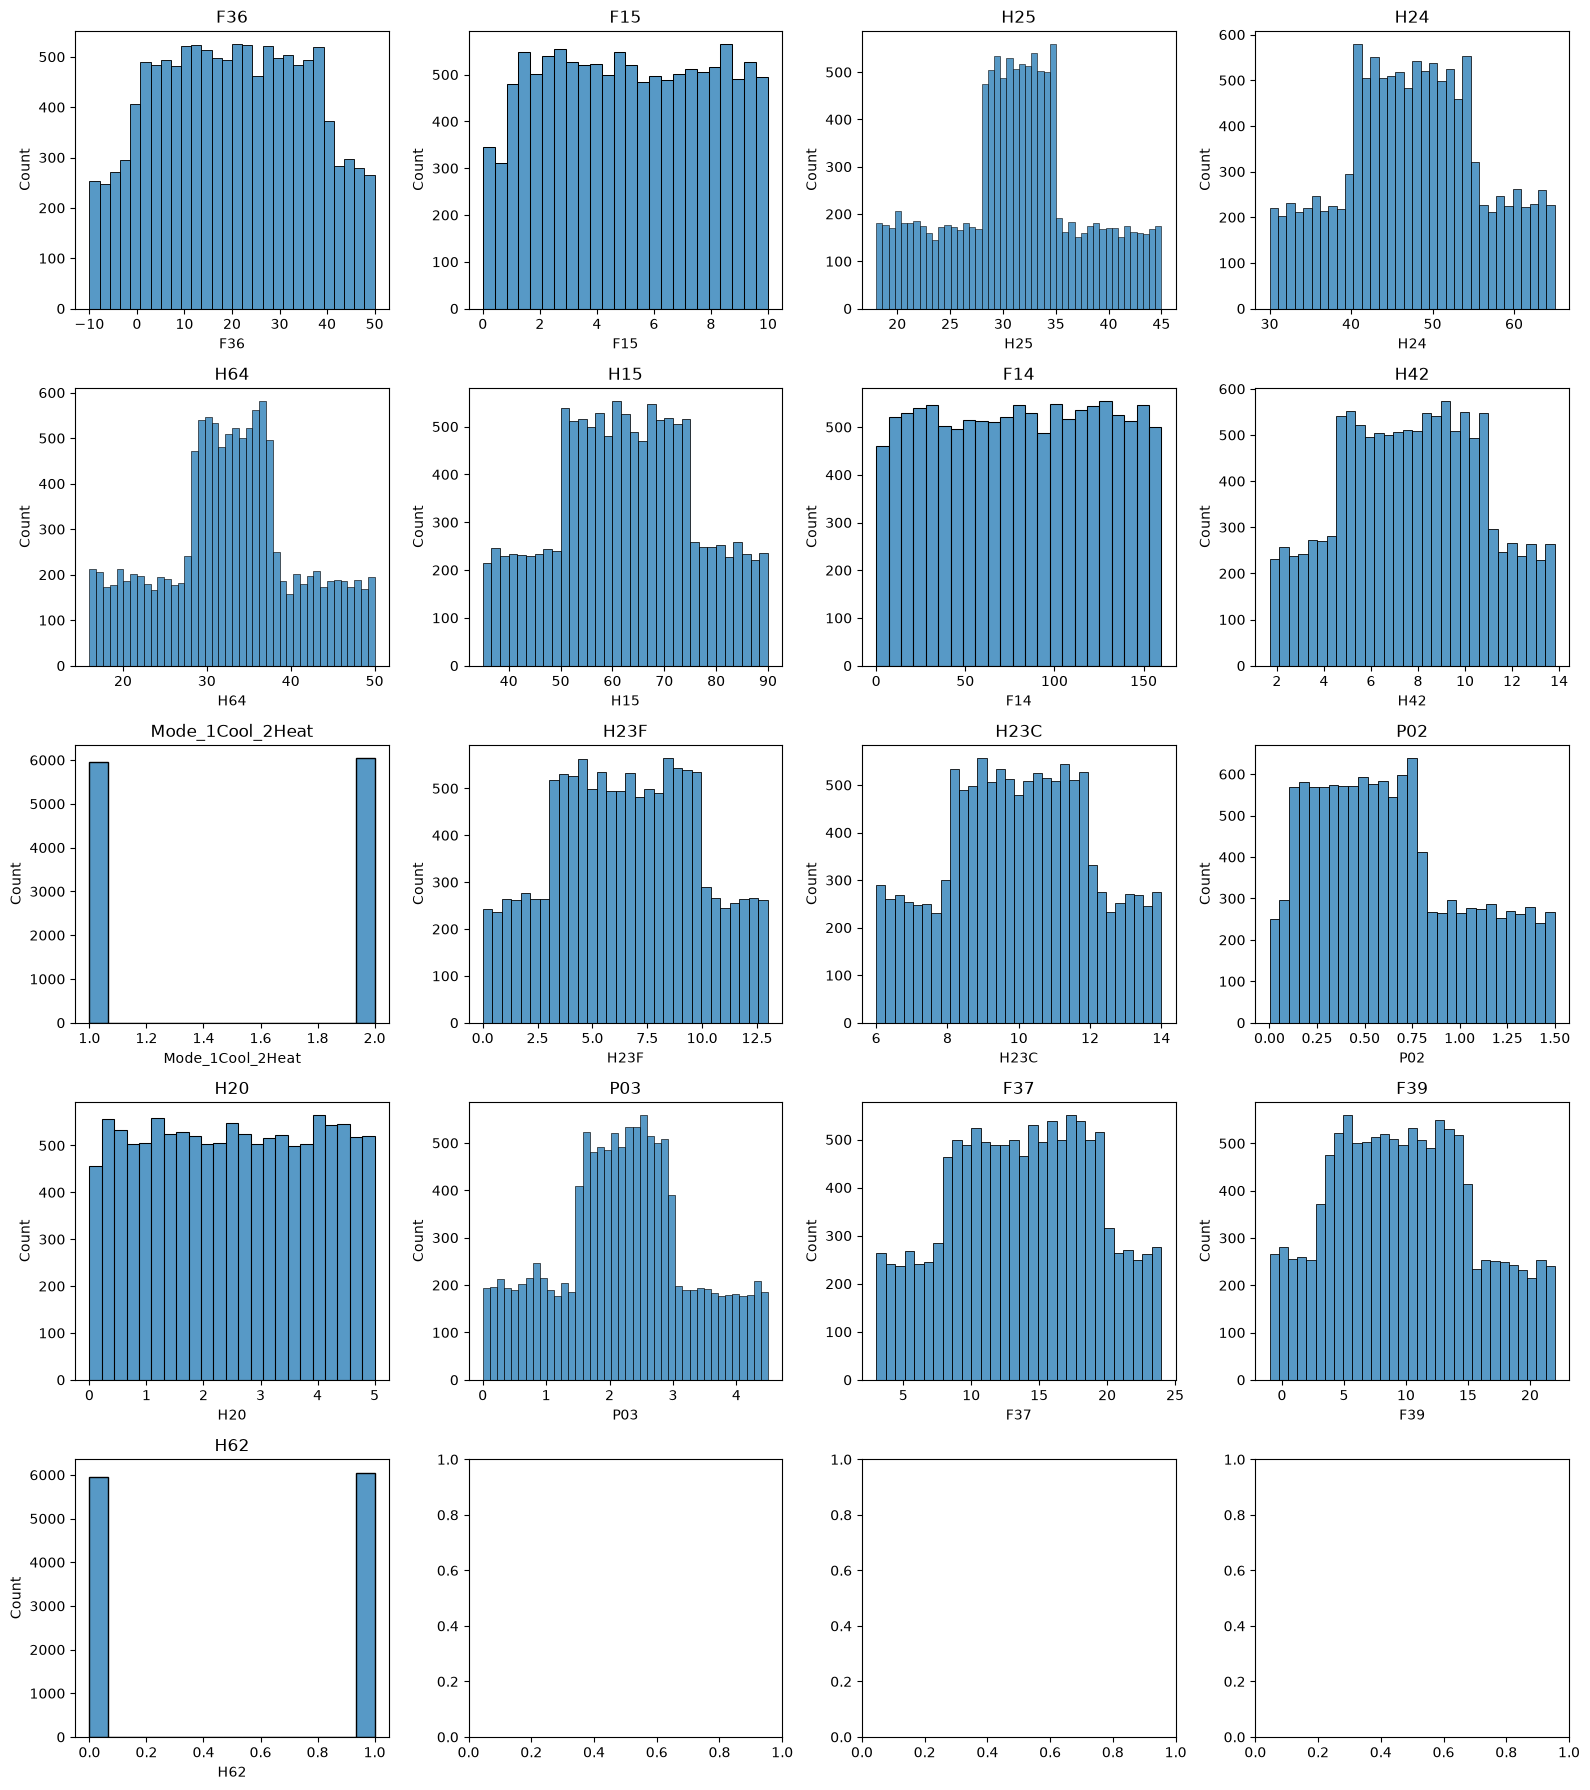

In [12]:
fig, axes = plt.subplots(5, 4, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(input_cols):
    sns.histplot(data=train_df, x=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Most variables have fairly broad, reasonably distributed ranges.

<Axes: >

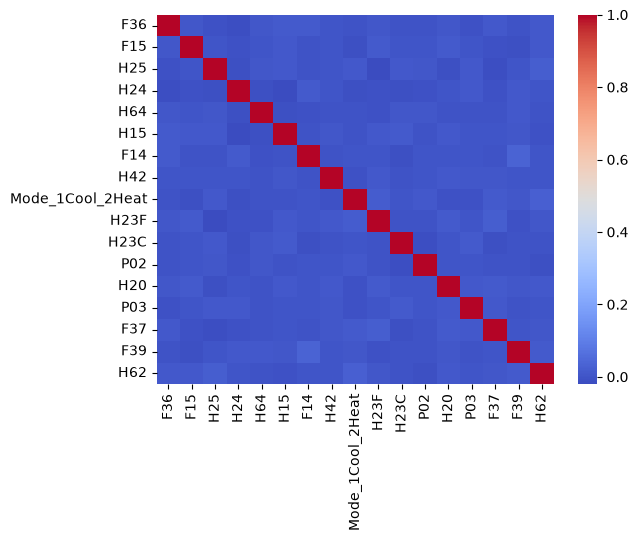

In [13]:
sns.heatmap(
    train_df[input_cols].corr(),
    fmt=".2f",
    cmap="coolwarm"
)

there aren't strong linear relationships among most of the input variables.

**EDA for output columns**

In [14]:
train_df[output_cols].describe()

,Chiller_Condenser_Fault,Chiller_ExpansionValve_Fault,Chiller_Evaporator_Fault,Chiller_Compressor_Fault,Chiller_General_Fault,Condenser_Valve_Fault,Condenser_Filter_Fault,Condenser_GasChargeNeeded,Condenser_Fan_Fault,Condenser_Coil_Fault,...,Evaporator_Electrical_Fault,Evaporator_FlowSwitch_Fault,Compressor_General_Fault,Compressor_Contactor_Fault,Compressor_Leak,Compressor_OilLoss,Compressor_SuperheatIncreaseNeeded,General_Electrical_Fault,General_LowPerformance,General_UnitUndersizedOversized
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,0.361208,0.240307,0.481023,0.456867,0.395727,0.150849,0.150849,0.191881,0.155982,0.144878,...,0.156252,0.350807,0.456437,0.220263,0.310175,0.220263,0.208552,0.103678,0.199368,0.366731
std,0.118110,0.116575,0.095043,0.071027,0.106251,0.184855,0.184855,0.272349,0.187102,0.172818,...,0.080484,0.241997,0.248117,0.144510,0.193208,0.144510,0.154590,0.089036,0.201131,0.326941
min,0.166000,0.166000,0.166000,0.166000,0.166000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.260247,0.166000,0.496440,0.424648,0.328515,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.166000,0.166000,0.371015,0.166000,0.167140,0.166000,0.166000,0.000000,0.000000,0.000000
50%,0.396205,0.166630,0.502880,0.478755,0.428150,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.166000,0.211345,0.502900,0.178030,0.359530,0.178030,0.171675,0.166000,0.166000,0.491830
75%,0.467662,0.312283,0.518230,0.497800,0.482492,0.200770,0.200770,0.196370,0.272108,0.206882,...,0.166000,0.514695,0.606960,0.359237,0.473740,0.359237,0.207473,0.168080,0.402618,0.625300
max,0.688370,0.663650,0.834000,0.830640,0.759930,0.500000,0.500000,0.834000,0.821560,0.500000,...,0.826150,0.834000,0.834000,0.500000,0.822220,0.500000,0.819000,0.611650,0.791000,0.834000


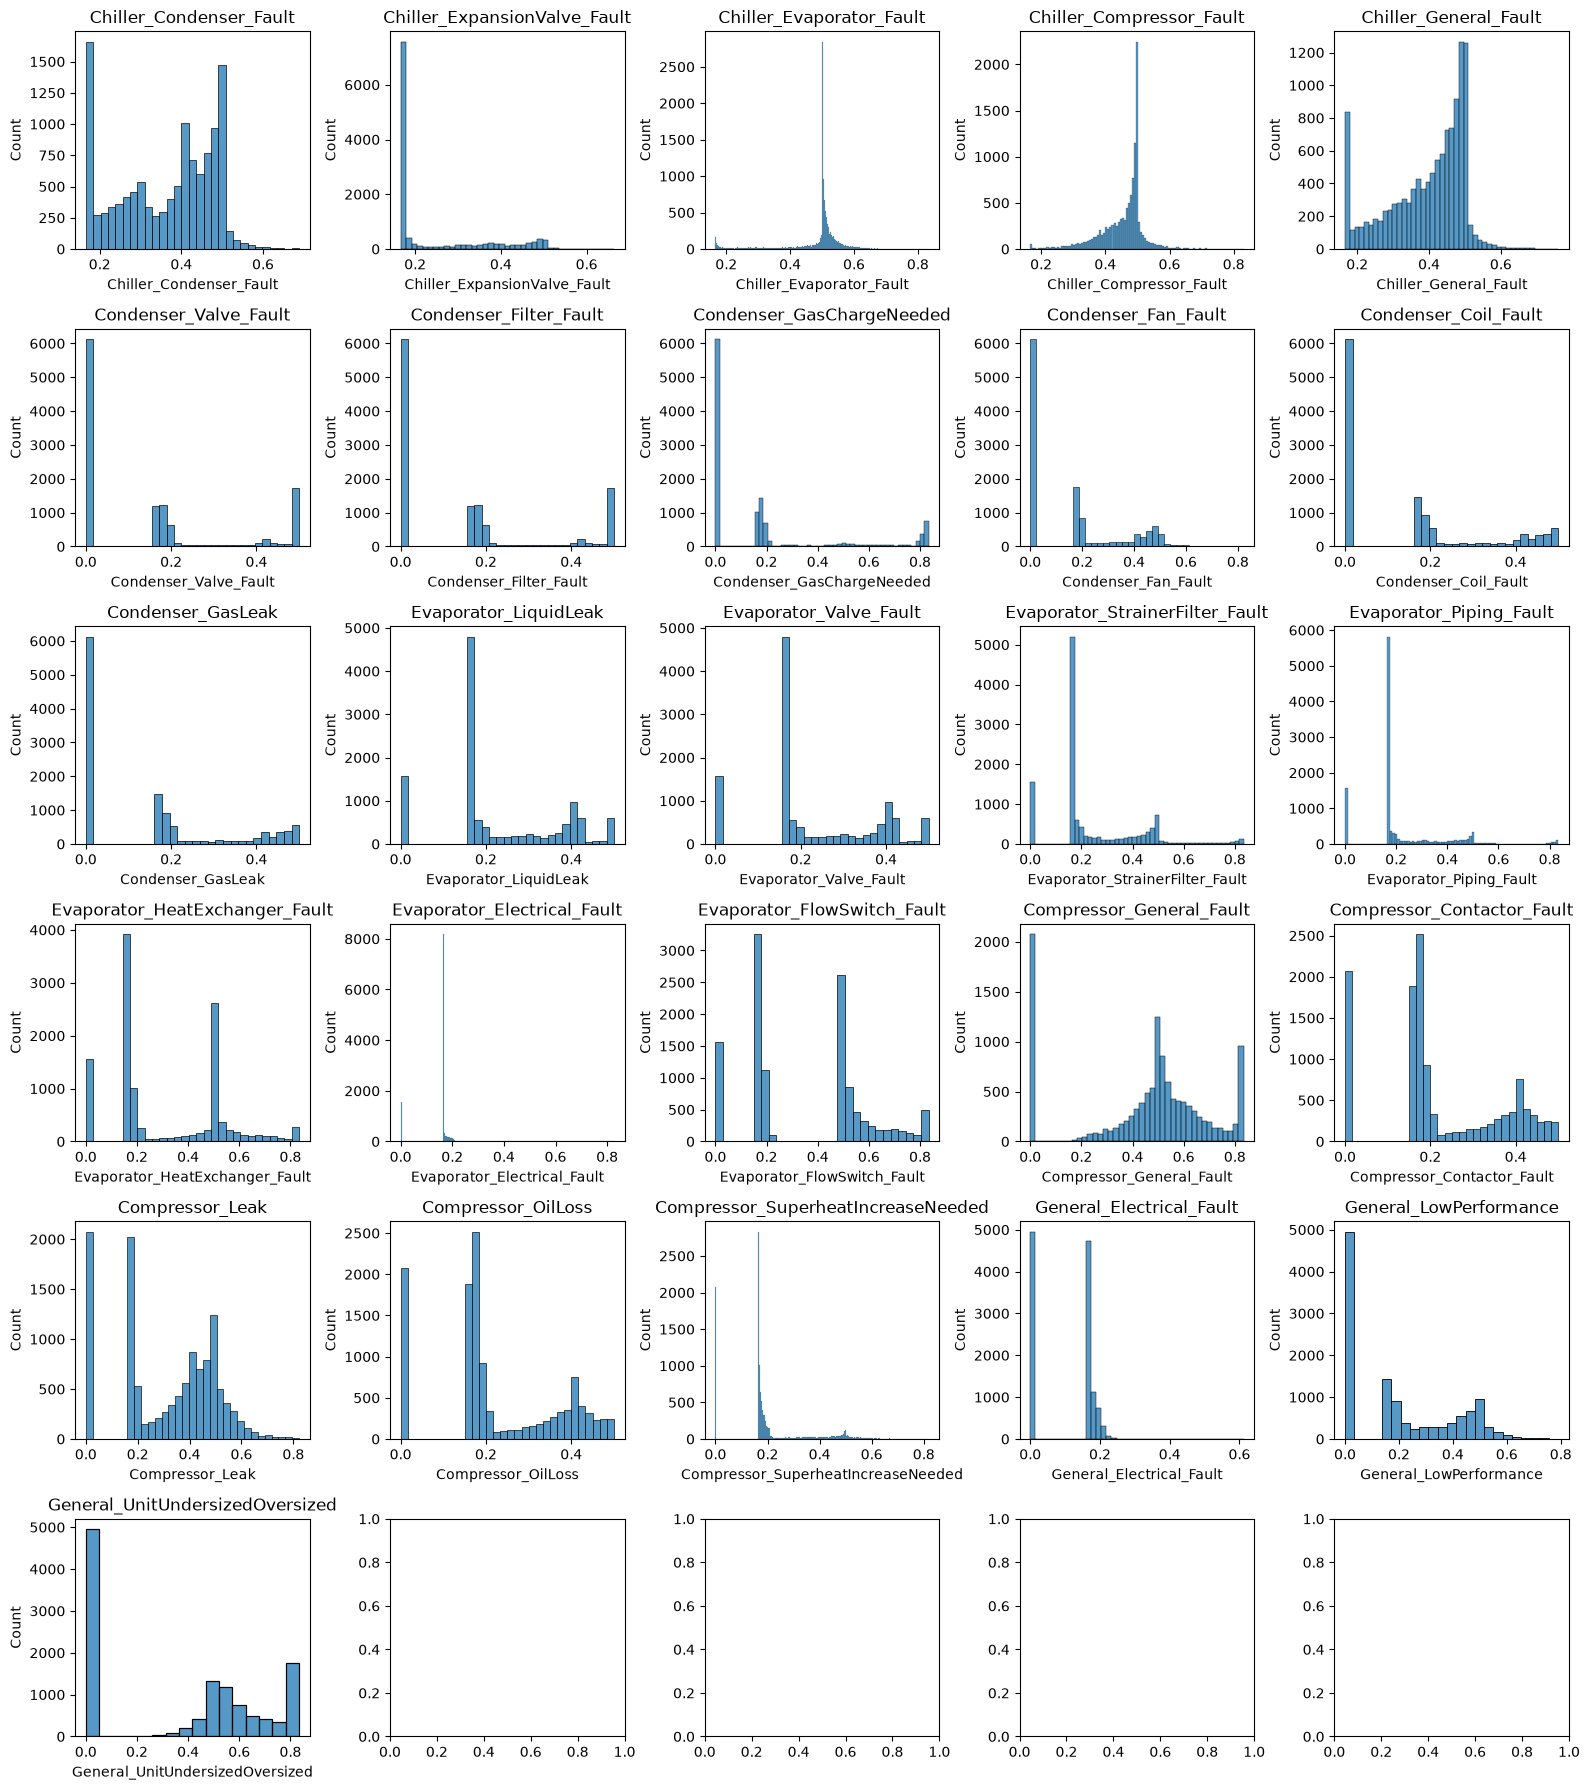

In [15]:
fig1, axes1 = plt.subplots(6, 5, figsize=(16, 18))
axes1=axes1.flatten()

for i, col in enumerate(output_cols):
  sns.histplot(data=train_df, x=col, ax=axes1[i])
  axes1[i].set_title(col)

plt.tight_layout()
plt.show()

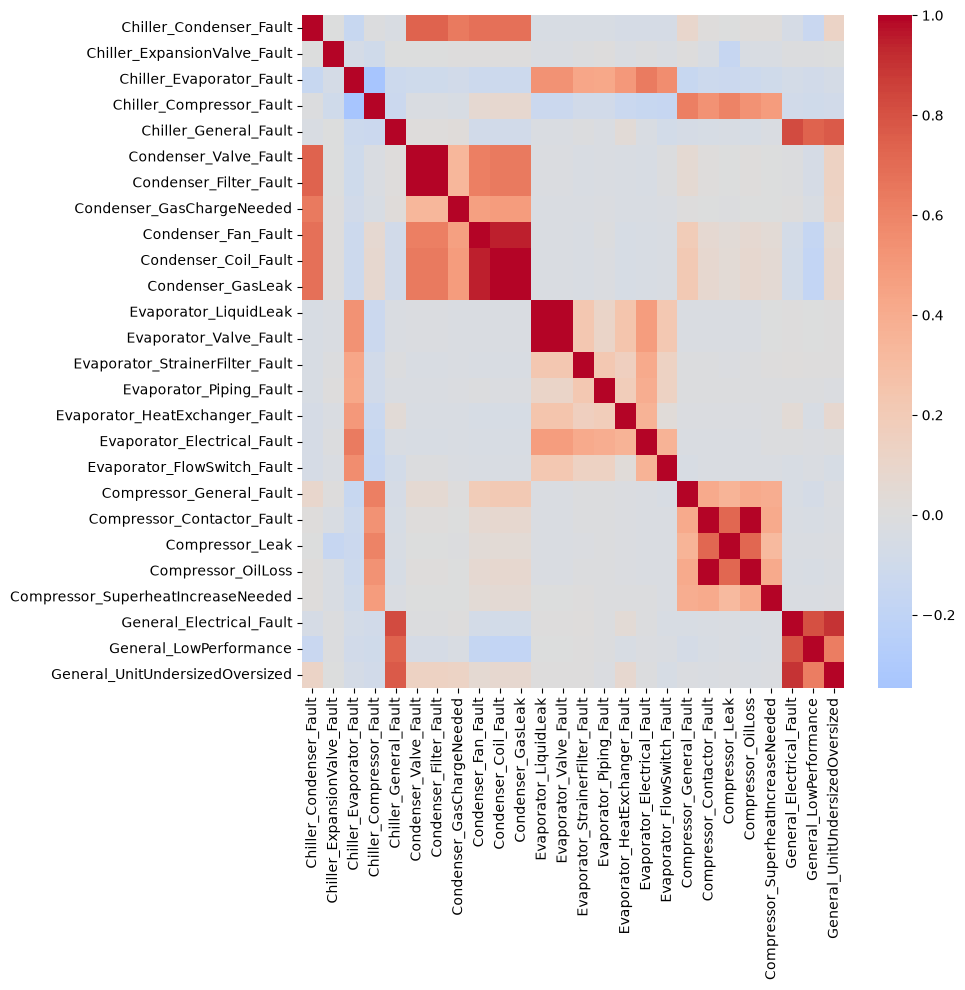

In [16]:
plt.figure(figsize=(10, 10))

sns.heatmap(
    train_df[output_cols].corr(),
    cmap="coolwarm",
    center=0
)

plt.tight_layout()
plt.show()

In [17]:
corr_io = train_df[input_cols + output_cols].corr()
io_corr = corr_io.loc[input_cols, output_cols]

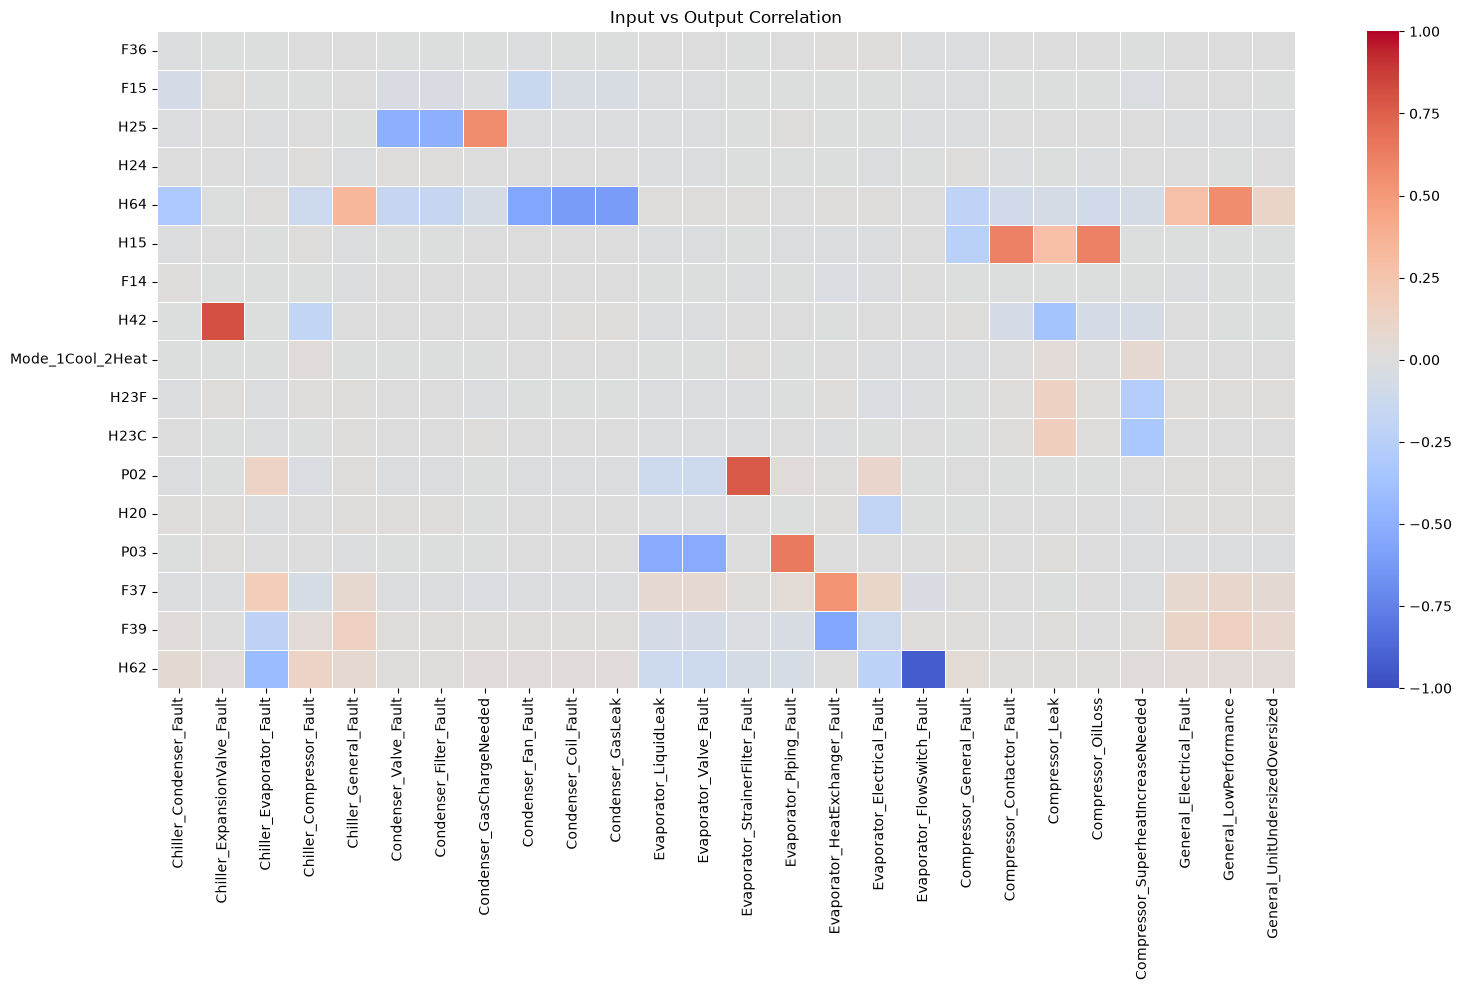

In [18]:
plt.figure(figsize=(16, 10))
sns.heatmap(
    io_corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=.5
)
plt.title("Input vs Output Correlation")
plt.tight_layout()
plt.show()

In [19]:
strong_corr = (
    io_corr.stack()
    .reset_index()
)

strong_corr.columns = ["Input", "Output", "Correlation"]

strong_corr["Strength"] = strong_corr["Correlation"].abs()

strong_corr = strong_corr.sort_values(
    "Strength",
    ascending=False
)

strong_corr.head(15)

,Input,Output,Correlation,Strength
433,H62,Evaporator_FlowSwitch_Fault,-0.922461,0.922461
183,H42,Chiller_ExpansionValve_Fault,0.806753,0.806753
299,P02,Evaporator_StrainerFilter_Fault,0.772253,0.772253
352,P03,Evaporator_Piping_Fault,0.643983,0.643983
113,H64,Condenser_Coil_Fault,-0.616242,0.616242
114,H64,Condenser_GasLeak,-0.616242,0.616242
151,H15,Compressor_OilLoss,0.616196,0.616196
149,H15,Compressor_Contactor_Fault,0.616196,0.616196
59,H25,Condenser_GasChargeNeeded,0.559643,0.559643
128,H64,General_LowPerformance,0.559435,0.559435


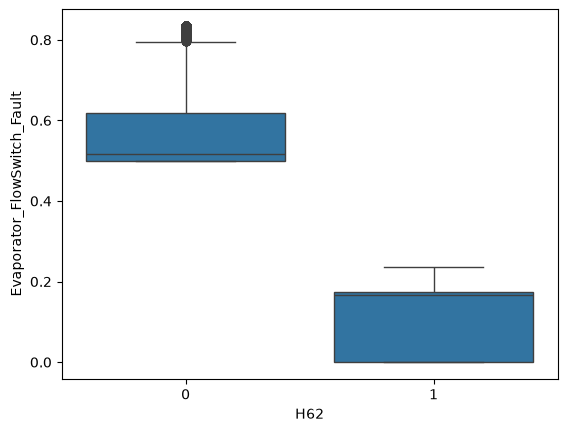

In [20]:
sns.boxplot(data=train_df, x='H62', y='Evaporator_FlowSwitch_Fault')
plt.show()

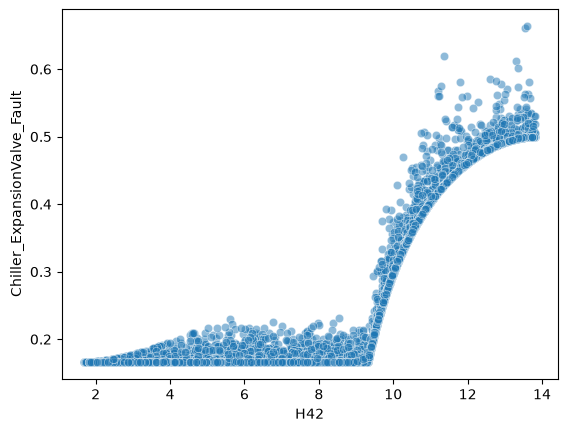

In [21]:
sns.scatterplot(data=train_df, x='H42', y='Chiller_ExpansionValve_Fault', alpha=0.5)
plt.show()

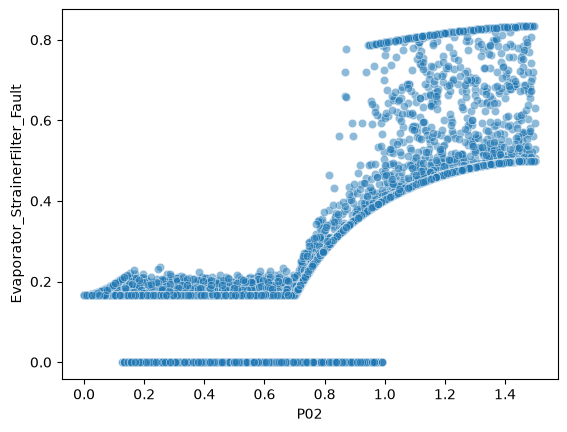

In [22]:
sns.scatterplot(data=train_df, x='P02', y='Evaporator_StrainerFilter_Fault', alpha=0.5)
plt.show()

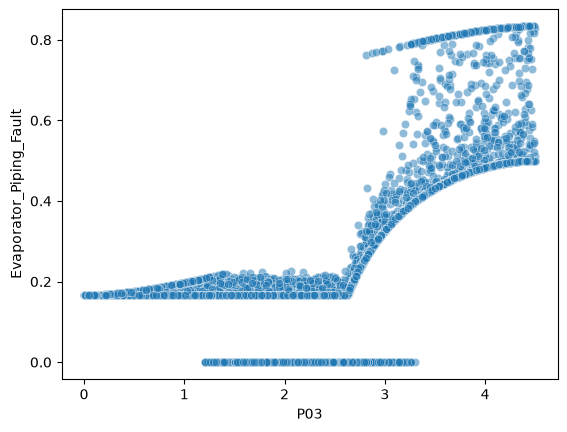

In [23]:
sns.scatterplot(data=train_df, x='P03', y='Evaporator_Piping_Fault', alpha=0.5)
plt.show()

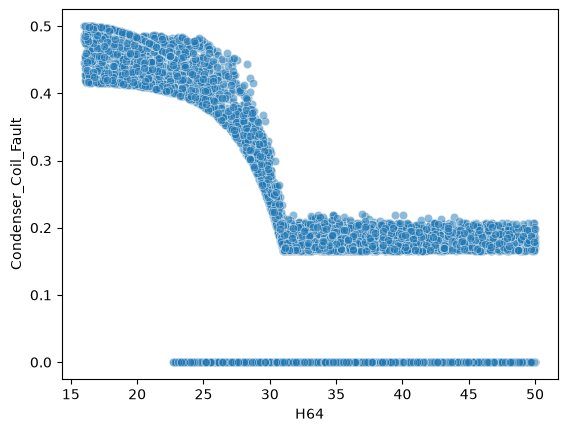

In [24]:
sns.scatterplot(data=train_df, x='H64', y='Condenser_Coil_Fault', alpha=0.5)
plt.show()

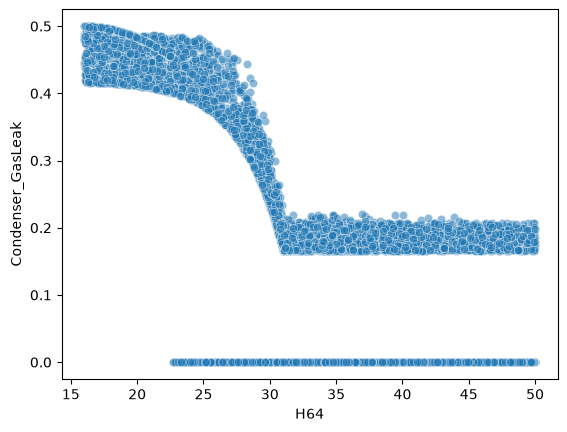

In [25]:
sns.scatterplot(data=train_df, x='H64', y='Condenser_GasLeak', alpha=0.5)
plt.show()

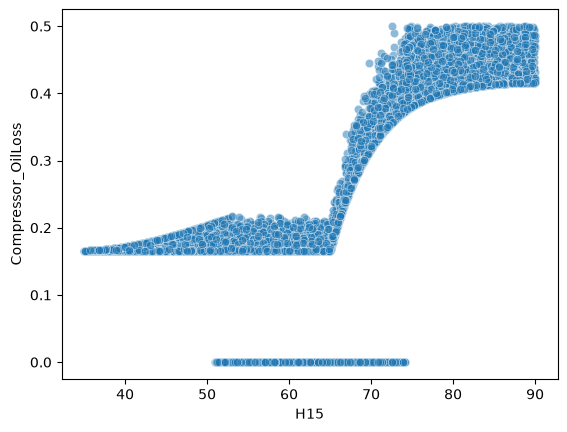

In [26]:
sns.scatterplot(data=train_df, x='H15', y='Compressor_OilLoss', alpha=0.5)
plt.show()

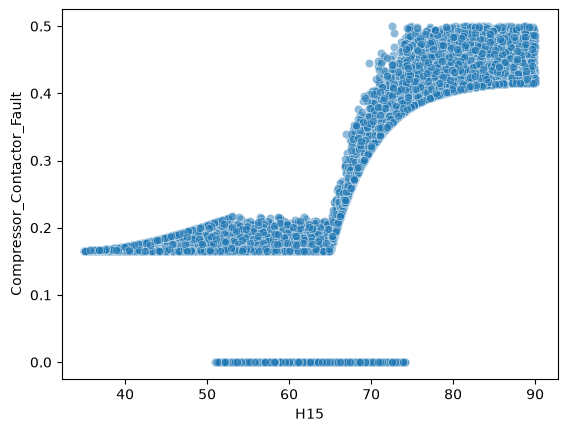

In [27]:
sns.scatterplot(data=train_df, x='H15', y='Compressor_Contactor_Fault', alpha=0.5)
plt.show()

### Random Forest

In [28]:
X = train_df[input_cols]
Y = train_df[output_cols]

In [29]:
X.shape, Y.shape

((12000, 17), (12000, 26))

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, Y_train)

Y_pred = rf_model.predict(X_val)

In [31]:
Y_pred.shape

(2400, 26)

In [32]:
error = Y_val - Y_pred  # DataFrame of shape (n_samples, 26)

mae_per  = error.abs().mean()
mse_per  = (error ** 2).mean()
rmse_per = np.sqrt(mse_per)

# Overall (averaged across all 26)
mae_avg  = mae_per.mean()
mse_avg  = mse_per.mean()
rmse_avg = np.sqrt(mse_avg)

In [33]:
mae_per

Chiller_Condenser_Fault               0.043514
Chiller_ExpansionValve_Fault          0.068191
Chiller_Evaporator_Fault              0.028645
Chiller_Compressor_Fault              0.040112
Chiller_General_Fault                 0.044300
Condenser_Valve_Fault                 0.019649
Condenser_Filter_Fault                0.019649
Condenser_GasChargeNeeded             0.025731
Condenser_Fan_Fault                   0.036129
Condenser_Coil_Fault                  0.024192
Condenser_GasLeak                     0.024192
Evaporator_LiquidLeak                 0.056024
Evaporator_Valve_Fault                0.056024
Evaporator_StrainerFilter_Fault       0.055595
Evaporator_Piping_Fault               0.054212
Evaporator_HeatExchanger_Fault        0.085227
Evaporator_Electrical_Fault           0.024510
Evaporator_FlowSwitch_Fault           0.039751
Compressor_General_Fault              0.139927
Compressor_Contactor_Fault            0.057259
Compressor_Leak                       0.114990
Compressor_Oi

In [34]:
mse_per

Chiller_Condenser_Fault               0.003304
Chiller_ExpansionValve_Fault          0.007664
Chiller_Evaporator_Fault              0.002018
Chiller_Compressor_Fault              0.002989
Chiller_General_Fault                 0.003442
Condenser_Valve_Fault                 0.002062
Condenser_Filter_Fault                0.002062
Condenser_GasChargeNeeded             0.003159
Condenser_Fan_Fault                   0.006091
Condenser_Coil_Fault                  0.002928
Condenser_GasLeak                     0.002928
Evaporator_LiquidLeak                 0.005717
Evaporator_Valve_Fault                0.005717
Evaporator_StrainerFilter_Fault       0.006416
Evaporator_Piping_Fault               0.006236
Evaporator_HeatExchanger_Fault        0.013915
Evaporator_Electrical_Fault           0.003890
Evaporator_FlowSwitch_Fault           0.003826
Compressor_General_Fault              0.035116
Compressor_Contactor_Fault            0.006574
Compressor_Leak                       0.022118
Compressor_Oi

In [35]:
rmse_per

Chiller_Condenser_Fault               0.057484
Chiller_ExpansionValve_Fault          0.087547
Chiller_Evaporator_Fault              0.044921
Chiller_Compressor_Fault              0.054673
Chiller_General_Fault                 0.058672
Condenser_Valve_Fault                 0.045407
Condenser_Filter_Fault                0.045407
Condenser_GasChargeNeeded             0.056206
Condenser_Fan_Fault                   0.078043
Condenser_Coil_Fault                  0.054114
Condenser_GasLeak                     0.054114
Evaporator_LiquidLeak                 0.075614
Evaporator_Valve_Fault                0.075614
Evaporator_StrainerFilter_Fault       0.080102
Evaporator_Piping_Fault               0.078966
Evaporator_HeatExchanger_Fault        0.117961
Evaporator_Electrical_Fault           0.062371
Evaporator_FlowSwitch_Fault           0.061854
Compressor_General_Fault              0.187394
Compressor_Contactor_Fault            0.081080
Compressor_Leak                       0.148722
Compressor_Oi

In [36]:
print("mae_avg",mae_avg)
print("mse_avg",mse_avg)
print("rmse_avg",rmse_avg)

mae_avg 0.054571951584134595
mse_avg 0.008160832577226716
rmse_avg 0.09033732659995378


In [37]:
from sklearn.metrics import r2_score

r2_per = r2_score(Y_val, Y_pred, multioutput='raw_values')

r2_avg = r2_score(Y_val, Y_pred, multioutput='uniform_average')

r2_vw = r2_score(Y_val, Y_pred, multioutput='variance_weighted')

In [38]:
r2_per

array([0.76595823, 0.43328263, 0.77637698, 0.43200393, 0.69769171,
       0.93993259, 0.93993259, 0.9568898 , 0.82602342, 0.903673  ,
       0.903673  , 0.70532583, 0.70532583, 0.78493453, 0.79809493,
       0.71600626, 0.41589613, 0.93320999, 0.42472428, 0.6801995 ,
       0.42168234, 0.6801995 , 0.21253835, 0.74953691, 0.81414285,
       0.72925043])

In [39]:
r2_avg

0.7056348295434776

In [40]:
r2_vw

0.7424016747869012

In [41]:
Y_train_pred = rf_model.predict(X_train)

In [42]:
from sklearn.metrics import r2_score

# Per-output training R²
r2_train_per = r2_score(
    Y_train,
    Y_train_pred,
    multioutput='raw_values'
)

# Average training R²
r2_train_avg = r2_score(
    Y_train,
    Y_train_pred,
    multioutput='uniform_average'
)

# Variance-weighted training R²
r2_train_vw = r2_score(
    Y_train,
    Y_train_pred,
    multioutput='variance_weighted'
)

print("Training average R²:", r2_train_avg)
print("Training variance-weighted R²:", r2_train_vw)

Training average R²: 0.9595866216554685
Training variance-weighted R²: 0.9644952604716632


In [43]:
r2_train_per

array([0.96608537, 0.92391855, 0.97041163, 0.91976909, 0.95777303,
       0.99080285, 0.99080285, 0.99312438, 0.97217855, 0.98593152,
       0.98593152, 0.96122434, 0.96122434, 0.97260697, 0.97021541,
       0.96424852, 0.92509004, 0.99109891, 0.92397797, 0.95595801,
       0.91898543, 0.95595801, 0.89262446, 0.96425271, 0.97464995,
       0.96040775])

In [44]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

depths = [10, 15, 20, 25, None]

results = []

for depth in depths:
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    # Train
    rf.fit(X_train, Y_train)

    # Predictions
    Y_train_pred = rf.predict(X_train)
    Y_val_pred = rf.predict(X_val)

    # R²
    train_r2 = r2_score(Y_train, Y_train_pred, multioutput="uniform_average")
    val_r2 = r2_score(Y_val, Y_val_pred, multioutput="uniform_average")

    # MAE
    val_mae = mean_absolute_error(Y_val, Y_val_pred)

    # RMSE
    val_rmse = np.sqrt(mean_squared_error(Y_val, Y_val_pred))

    results.append({
        "max_depth": depth,
        "train_R2": train_r2,
        "val_R2": val_r2,
        "val_MAE": val_mae,
        "val_RMSE": val_rmse
    })

results_df = pd.DataFrame(results)

results_df

,max_depth,train_R2,val_R2,val_MAE,val_RMSE
0,10.0,0.666596,0.591793,0.068455,0.106485
1,15.0,0.879279,0.682633,0.057325,0.093260
2,20.0,0.949186,0.702425,0.054940,0.090768
3,25.0,0.958745,0.705633,0.054573,0.090337
4,NaN,0.959587,0.705635,0.054572,0.090337


In [45]:

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


leaf_sizes = [1, 2, 5, 10, 20]

results_leaf = []

for leaf in leaf_sizes:
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )

    # Train
    rf.fit(X_train, Y_train)

    # Predictions
    Y_train_pred = rf.predict(X_train)
    Y_val_pred = rf.predict(X_val)

    # R²
    train_r2 = r2_score(
        Y_train, Y_train_pred,
        multioutput="uniform_average"
    )

    val_r2 = r2_score(
        Y_val, Y_val_pred,
        multioutput="uniform_average"
    )

    # MAE
    val_mae = mean_absolute_error(Y_val, Y_val_pred)

    # RMSE
    val_rmse = np.sqrt(
        mean_squared_error(Y_val, Y_val_pred)
    )

    results_leaf.append({
        "min_samples_leaf": leaf,
        "train_R2": train_r2,
        "val_R2": val_r2,
        "val_MAE": val_mae,
        "val_RMSE": val_rmse
    })

results_leaf_df = pd.DataFrame(results_leaf)

results_leaf_df

,min_samples_leaf,train_R2,val_R2,val_MAE,val_RMSE
0,1,0.949186,0.702425,0.054940,0.090768
1,2,0.893406,0.698501,0.055331,0.091214
2,5,0.795134,0.674962,0.058309,0.094576
3,10,0.717726,0.642082,0.062493,0.099555
4,20,0.643476,0.599516,0.067811,0.106228


In [46]:
feature_options = [1.0, 0.75, 0.5, "sqrt"]

results_features = []

for mf in feature_options:
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=1,
        max_features=mf,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, Y_train)

    Y_train_pred = rf.predict(X_train)
    Y_val_pred = rf.predict(X_val)

    train_r2 = r2_score(
        Y_train, Y_train_pred,
        multioutput="uniform_average"
    )

    val_r2 = r2_score(
        Y_val, Y_val_pred,
        multioutput="uniform_average"
    )

    val_mae = mean_absolute_error(Y_val, Y_val_pred)

    val_rmse = np.sqrt(
        mean_squared_error(Y_val, Y_val_pred)
    )

    results_features.append({
        "max_features": mf,
        "train_R2": train_r2,
        "val_R2": val_r2,
        "val_MAE": val_mae,
        "val_RMSE": val_rmse
    })

results_features_df = pd.DataFrame(results_features)

results_features_df

,max_features,train_R2,val_R2,val_MAE,val_RMSE
0,1.0,0.949186,0.702425,0.054940,0.090768
1,0.75,0.949383,0.708106,0.055312,0.090054
2,0.5,0.948132,0.702282,0.057197,0.091275
3,sqrt,0.943049,0.683537,0.063381,0.095603


In [47]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

rf_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=1,
    max_features=0.75,
    random_state=42,
    n_jobs=-1
)

# Train
rf_tuned.fit(X_train, Y_train)

# Predictions
Y_train_pred_tuned = rf_tuned.predict(X_train)
Y_val_pred_tuned = rf_tuned.predict(X_val)

# R²
train_r2_tuned = r2_score(
    Y_train, Y_train_pred_tuned,
    multioutput="uniform_average"
)

val_r2_tuned = r2_score(
    Y_val, Y_val_pred_tuned,
    multioutput="uniform_average"
)

# MAE
val_mae_tuned = mean_absolute_error(
    Y_val, Y_val_pred_tuned
)

# RMSE
val_rmse_tuned = np.sqrt(
    mean_squared_error(Y_val, Y_val_pred_tuned)
)

print("Training R²:", train_r2_tuned)
print("Validation R²:", val_r2_tuned)
print("Validation MAE:", val_mae_tuned)
print("Validation RMSE:", val_rmse_tuned)

Training R²: 0.9493831922614677
Validation R²: 0.7081057565268657
Validation MAE: 0.055312183988173946
Validation RMSE: 0.09005439442151984


In [48]:
print("===== FINAL RANDOM FOREST RESULTS =====")
print(f"Training R²:       {train_r2_tuned:.4f}")
print(f"Validation R²:     {val_r2_tuned:.4f}")
print(f"Validation R² %:   {val_r2_tuned * 100:.2f}%")
print(f"Validation MAE:    {val_mae_tuned:.4f}")
print(f"Validation RMSE:   {val_rmse_tuned:.4f}")

===== FINAL RANDOM FOREST RESULTS =====
Training R²:       0.9494
Validation R²:     0.7081
Validation R² %:   70.81%
Validation MAE:    0.0553
Validation RMSE:   0.0901


In [49]:
errors = np.abs(Y_val.values - Y_val_pred_tuned)

tolerances = [0.01, 0.05, 0.10]

print("\n===== TOLERANCE-BASED PREDICTION RATE =====")

for tol in tolerances:
    percentage = np.mean(errors <= tol) * 100
    print(f"Within ±{tol:.2f}: {percentage:.2f}%")


===== TOLERANCE-BASED PREDICTION RATE =====
Within ±0.01: 23.90%
Within ±0.05: 64.95%
Within ±0.10: 83.49%


In [50]:
X_full = train_df[input_cols]
Y_full = train_df[output_cols]

X_holdout = holdout_df[input_cols]
Y_holdout = holdout_df[output_cols]

In [51]:
from sklearn.ensemble import RandomForestRegressor

final_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=1,
    max_features=0.75,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_full, Y_full)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.75
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"ma

In [52]:
Y_holdout_pred_rf = final_rf.predict(X_holdout)

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

holdout_rf_mae = mean_absolute_error(
    Y_holdout,
    Y_holdout_pred_rf
)

holdout_rf_rmse = np.sqrt(
    mean_squared_error(
        Y_holdout,
        Y_holdout_pred_rf
    )
)

holdout_rf_r2 = r2_score(
    Y_holdout,
    Y_holdout_pred_rf,
    multioutput="uniform_average"
)

print("RF Holdout R²:", holdout_rf_r2)
print("RF Holdout MAE:", holdout_rf_mae)
print("RF Holdout RMSE:", holdout_rf_rmse)

RF Holdout R²: 0.48963623597055367
RF Holdout MAE: 0.09380317899060585
RF Holdout RMSE: 0.14630661904226877
